# 01 — Data Exploration

Explore the raw options data from DoltHub, underlying OHLCV, volatility history features,
and the processed tensors that feed the SurfaceAlpha model.

**Prerequisites:** Run `make data` (or at minimum `make fetch` and `make canonical`) so that
`data/liquid_core/raw/` and `data/liquid_core/canonical/` are populated.

In [14]:
import sys
import os
from pathlib import Path
if Path(os.getcwd()).name == 'notebooks':
    os.chdir('..')
sys.path.append(os.path.abspath('src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

from volregime.utils.config import load_config

cfg = load_config()
# Use the correct data path
data_dir = Path('data/liquid_core')
raw_dir = data_dir / 'raw'
canonical_dir = data_dir / 'canonical'
processed_dir = data_dir / 'processed'

print(f"Date range: {cfg['data']['date_range']}")
print(f"Active symbols: {cfg['active_symbols_list']}")
print(f"data_dir exists: {data_dir.exists()}")

Date range: {'start': '2015-01-02', 'end': '2026-03-20'}
Active symbols: ['SPY']
data_dir exists: True


## 1. Raw Option Chain Coverage

In [15]:
# Load the raw option chain data (exported by sa-fetch-options)
option_path = raw_dir / 'option_chain.parquet'
if option_path.exists():
    options_df = pd.read_parquet(option_path)
    options_df['date'] = pd.to_datetime(options_df['date'])
    print(f"Total rows: {len(options_df):,}")
    print(f"Symbols: {sorted(options_df['act_symbol'].unique())}")
    print(f"Date range: {options_df['date'].min()} -> {options_df['date'].max()}")
    if 'call_put' in options_df.columns:
        print(f"Call/Put breakdown: {options_df['call_put'].value_counts().to_dict()}")
    if 'obs_frequency' in options_df.columns:
        print(f"Obs frequency: {options_df['obs_frequency'].value_counts().to_dict()}")
    print(options_df.head())
else:
    print(f"No option chain file found at {option_path}. Run `make fetch` first.")

Total rows: 111,072,877
Symbols: ['AAPL', 'AMZN', 'AVGO', 'GOOGL', 'GS', 'IWM', 'JPM', 'META', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TSLA', 'XOM']
Date range: 2015-01-02 00:00:00 -> 2026-03-20 00:00:00
Call/Put breakdown: {'call': 55460904, 'put': 55460881, 'Call': 75546, 'Put': 75546}
        date act_symbol  expiration  strike call_put    bid    ask      vol  \
0 2015-01-02       AAPL  2015-01-02    70.0     call  39.15  39.45  0.01488   
1 2015-01-02       AAPL  2015-01-02    70.0      put   0.00   0.01  3.02944   
2 2015-01-02       AAPL  2015-01-02    75.0     call  34.15  34.45  0.01488   
3 2015-01-02       AAPL  2015-01-02    75.0      put   0.00   0.01  2.59042   
4 2015-01-02       AAPL  2015-01-02    80.0     call  29.15  29.45  0.01488   

     delta    gamma    theta     vega      rho  
0  1.00000  0.00000 -0.00023  0.00000  0.00192  
1 -0.00192  0.00035 -0.05293  0.00035 -0.00001  
2  1.00000  0.00000 -0.00025  0.00000  0.00205  
3 -0.00220  0.00047 -0.05132  0.00040 -0.00001  


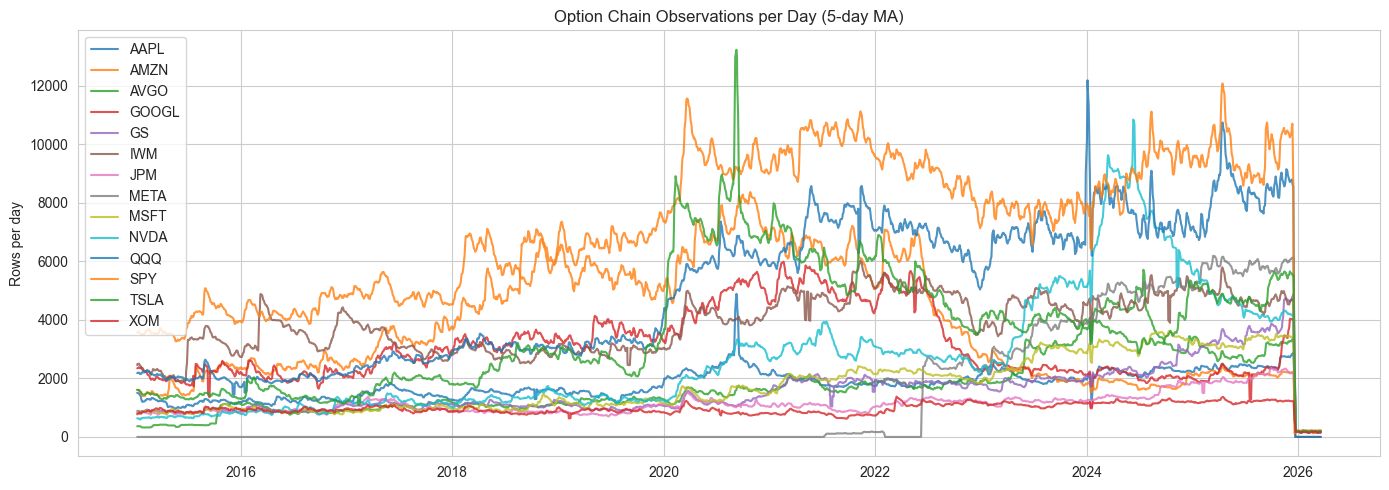

In [16]:
# Observation count per symbol over time
if 'options_df' in dir():
    daily_counts = options_df.groupby(['date', 'act_symbol']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(14, 5))
    for col in daily_counts.columns:
        ax.plot(daily_counts.index, daily_counts[col].rolling(5).mean(), label=col, alpha=0.8)
    ax.set_title('Option Chain Observations per Day (5-day MA)')
    ax.set_ylabel('Rows per day')
    ax.legend()
    plt.tight_layout()

## 2. Data Quality Before Filtering

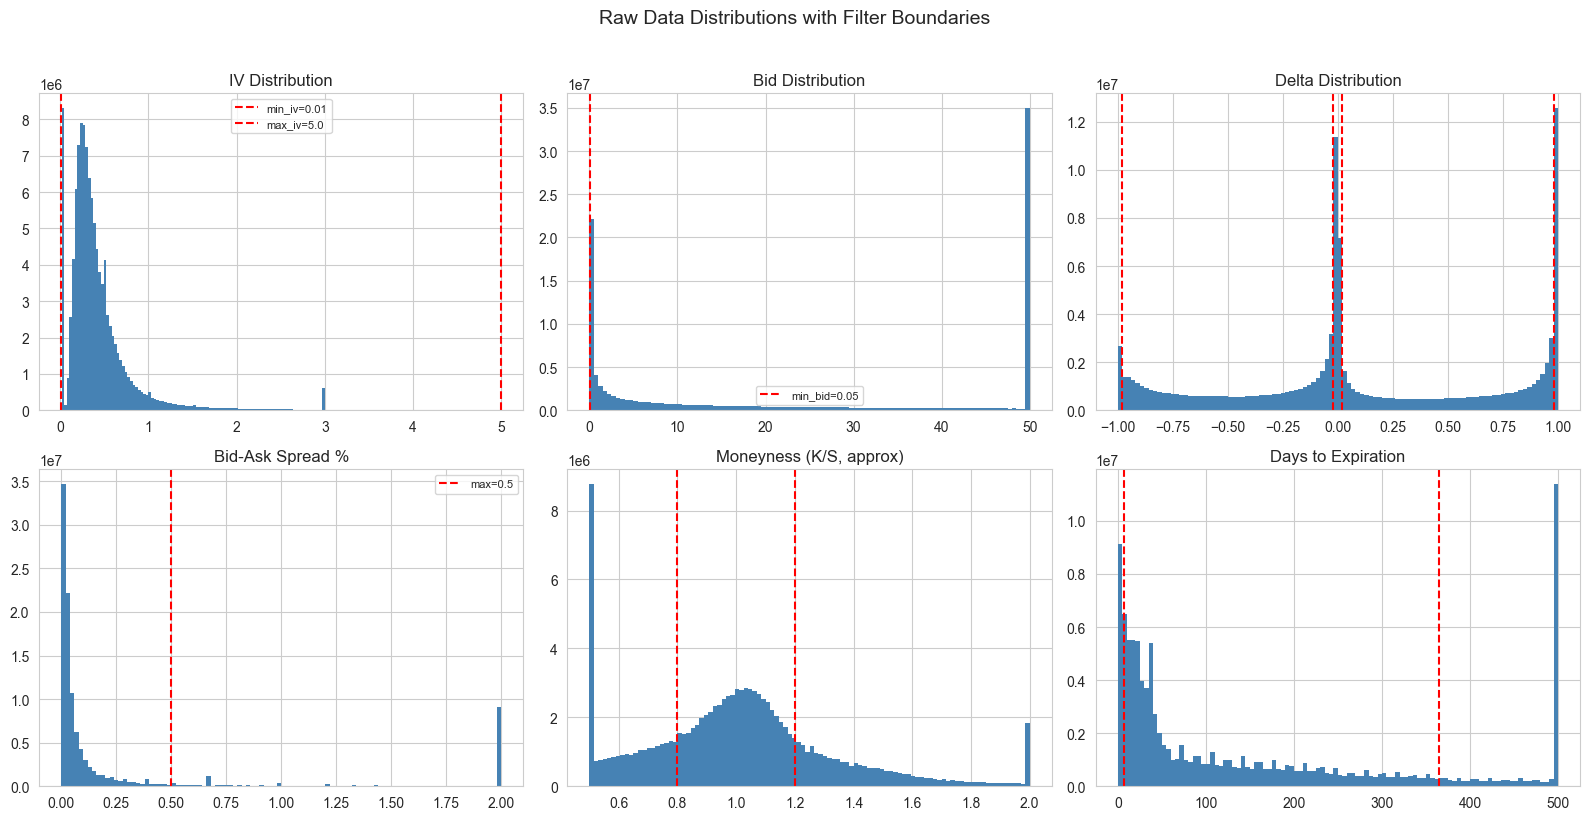

In [17]:
if 'options_df' in dir():
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    # Determine IV column name
    iv_col = 'iv' if 'iv' in options_df.columns else 'vol'

    # IV distribution
    ax = axes[0, 0]
    options_df[iv_col].clip(0, 3).hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
    ax.axvline(cfg['data']['filters']['min_iv'], color='red', ls='--', label=f"min_iv={cfg['data']['filters']['min_iv']}")
    ax.axvline(cfg['data']['filters']['max_iv'], color='red', ls='--', label=f"max_iv={cfg['data']['filters']['max_iv']}")
    ax.set_title('IV Distribution')
    ax.legend(fontsize=8)

    # Bid distribution
    ax = axes[0, 1]
    options_df['bid'].clip(0, 50).hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
    ax.axvline(cfg['data']['filters']['min_bid'], color='red', ls='--', label=f"min_bid={cfg['data']['filters']['min_bid']}")
    ax.set_title('Bid Distribution')
    ax.legend(fontsize=8)

    # Delta distribution
    ax = axes[0, 2]
    if 'delta' in options_df.columns:
        options_df['delta'].hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
        min_d = cfg['data']['filters']['min_delta_abs']
        max_d = cfg['data']['filters']['max_delta_abs']
        for v in [-max_d, -min_d, min_d, max_d]:
            ax.axvline(v, color='red', ls='--')
    ax.set_title('Delta Distribution')

    # Bid-ask spread
    ax = axes[1, 0]
    if 'ask' in options_df.columns and 'bid' in options_df.columns:
        mid = (options_df['ask'] + options_df['bid']) / 2
        spread_pct = ((options_df['ask'] - options_df['bid']) / mid.clip(lower=1e-6)).clip(0, 2)
        spread_pct.hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
        ax.axvline(cfg['data']['filters']['max_spread_pct'], color='red', ls='--',
                   label=f"max={cfg['data']['filters']['max_spread_pct']}")
        ax.legend(fontsize=8)
    ax.set_title('Bid-Ask Spread %')

    # Moneyness distribution (approximate)
    ax = axes[1, 1]
    if 'strike' in options_df.columns:
        approx_spot = options_df.groupby(['date', 'act_symbol'])['strike'].transform('median')
        moneyness = (options_df['strike'] / approx_spot).clip(0.5, 2.0)
        moneyness.hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
        ax.axvline(cfg['data']['moneyness']['min'], color='red', ls='--')
        ax.axvline(cfg['data']['moneyness']['max'], color='red', ls='--')
    ax.set_title('Moneyness (K/S, approx)')

    # Days to expiration
    ax = axes[1, 2]
    if 'expiration' in options_df.columns:
        dte = (pd.to_datetime(options_df['expiration']) - options_df['date']).dt.days
        dte.clip(0, 500).hist(bins=100, ax=ax, color='steelblue', edgecolor='none')
        if 'min_days' in cfg['data'].get('maturity', {}):
            ax.axvline(cfg['data']['maturity']['min_days'], color='red', ls='--')
            ax.axvline(cfg['data']['maturity']['max_days'], color='red', ls='--')
    ax.set_title('Days to Expiration')

    plt.suptitle('Raw Data Distributions with Filter Boundaries', fontsize=14, y=1.02)
    plt.tight_layout()

## 3. Underlying OHLCV

In [18]:
# Load underlying canonical data (has log_return already computed)
underlying_path = canonical_dir / 'underlying_canonical.parquet'
raw_underlying_path = raw_dir / 'underlying_all.parquet'

undl = None
if underlying_path.exists():
    undl = pd.read_parquet(underlying_path)
    undl['date'] = pd.to_datetime(undl['date'])
    print(f"Loaded from canonical: {len(undl):,} rows")
    print(f"Columns: {list(undl.columns)}")
    print(f"Symbols: {sorted(undl['symbol'].unique())}")
elif raw_underlying_path.exists():
    undl = pd.read_parquet(raw_underlying_path)
    undl['date'] = pd.to_datetime(undl['date'])
    print(f"Loaded from raw: {len(undl):,} rows")
    print(f"Columns: {list(undl.columns)}")
else:
    print(f"No underlying data found at {underlying_path} or {raw_underlying_path}")

Loaded from canonical: 42,364 rows
Columns: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'symbol', 'log_return']
Symbols: ['AAPL', 'AMZN', 'AVGO', 'GOOGL', 'GS', 'IWM', 'JPM', 'META', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TSLA', 'XOM']


AAPL: 3026 days, ann vol = 28.3%, min ret = -0.138, max ret = 0.143
AMZN: 3026 days, ann vol = 32.7%, min ret = -0.151, max ret = 0.132
AVGO: 3026 days, ann vol = 38.6%, min ret = -0.222, max ret = 0.219
GOOGL: 3026 days, ann vol = 28.2%, min ret = -0.124, max ret = 0.151
GS: 3026 days, ann vol = 28.5%, min ret = -0.136, max ret = 0.162
IWM: 3026 days, ann vol = 22.2%, min ret = -0.142, max ret = 0.088
JPM: 3026 days, ann vol = 26.5%, min ret = -0.162, max ret = 0.166
META: 3026 days, ann vol = 37.5%, min ret = -0.306, max ret = 0.209
MSFT: 3026 days, ann vol = 26.5%, min ret = -0.159, max ret = 0.133
NVDA: 3026 days, ann vol = 46.9%, min ret = -0.208, max ret = 0.261
QQQ: 3026 days, ann vol = 21.5%, min ret = -0.128, max ret = 0.113
SPY: 3026 days, ann vol = 17.4%, min ret = -0.116, max ret = 0.100
TSLA: 3026 days, ann vol = 56.4%, min ret = -0.237, max ret = 0.204
XOM: 3026 days, ann vol = 26.8%, min ret = -0.130, max ret = 0.119


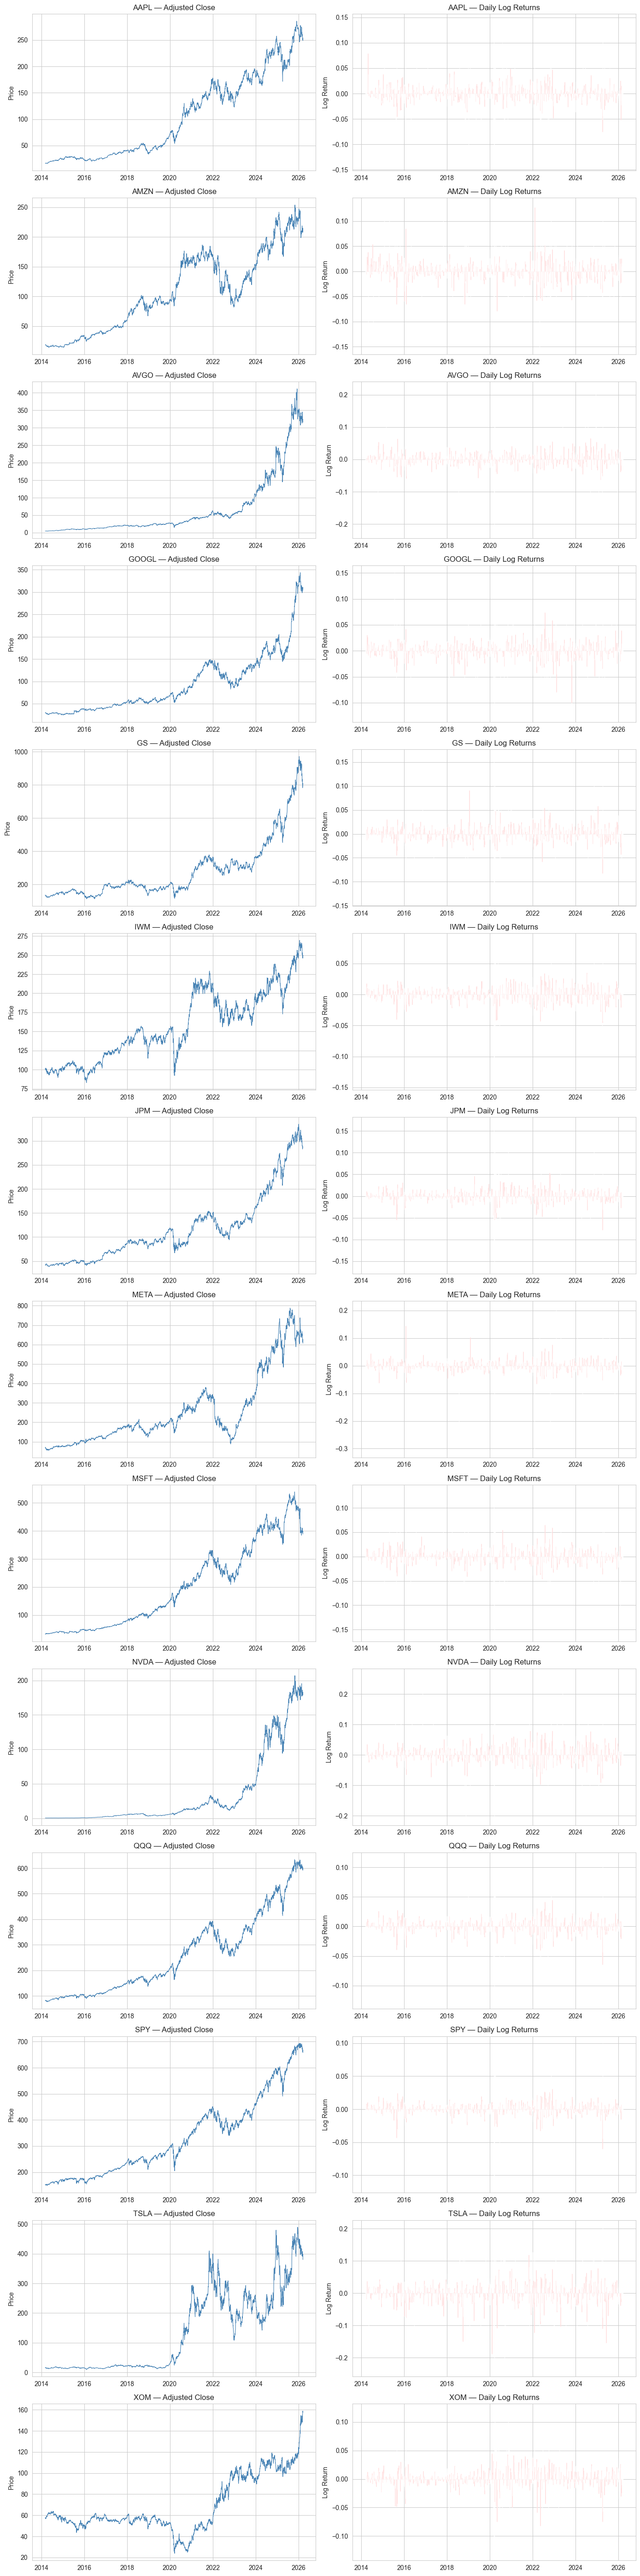

In [19]:
if undl is not None:
    sym_col = 'symbol' if 'symbol' in undl.columns else 'act_symbol'
    symbols = sorted(undl[sym_col].unique())

    fig, axes = plt.subplots(len(symbols), 2, figsize=(14, 4 * len(symbols)))
    if len(symbols) == 1:
        axes = axes.reshape(1, -1)

    for i, sym in enumerate(symbols):
        df = undl[undl[sym_col] == sym].sort_values('date').copy()

        # log_return should already be in canonical; if not, compute it
        if 'log_return' not in df.columns:
            close_col = 'adj_close' if 'adj_close' in df.columns else 'close'
            df['log_return'] = np.log(df[close_col] / df[close_col].shift(1))

        close_col = 'adj_close' if 'adj_close' in df.columns else 'close'
        axes[i, 0].plot(df['date'], df[close_col], color='steelblue', lw=0.8)
        axes[i, 0].set_title(f'{sym} — Adjusted Close')
        axes[i, 0].set_ylabel('Price')

        lr = df['log_return'].dropna()
        axes[i, 1].bar(df['date'].iloc[1:], df['log_return'].iloc[1:],
                       color='red', width=1, alpha=0.7)
        axes[i, 1].set_title(f'{sym} — Daily Log Returns')
        axes[i, 1].set_ylabel('Log Return')

        ann_vol = lr.std() * np.sqrt(252)
        print(f"{sym}: {len(df)} days, ann vol = {ann_vol:.1%}, "
              f"min ret = {lr.min():.3f}, max ret = {lr.max():.3f}")

    plt.tight_layout()

## 4. Volatility History Features

In [20]:
# Load vol history canonical
# Columns: date, act_symbol, hv_current, hv_week_ago, hv_month_ago, hv_year_high,
#          hv_year_high_date, hv_year_low, hv_year_low_date, iv_current,
#          iv_week_ago, iv_month_ago, iv_year_high, iv_year_high_date, iv_year_low
vh_canonical_path = canonical_dir / 'vol_history_canonical.parquet'
vh_raw_path = raw_dir / 'volatility_history.parquet'

vh = None
if vh_canonical_path.exists():
    vh = pd.read_parquet(vh_canonical_path)
    vh['date'] = pd.to_datetime(vh['date'])
    print(f"Loaded vol history canonical: {len(vh):,} rows")
    print(f"Columns: {list(vh.columns)}")
    print(f"Symbols (act_symbol): {sorted(vh['act_symbol'].unique())}")
elif vh_raw_path.exists():
    vh = pd.read_parquet(vh_raw_path)
    vh['date'] = pd.to_datetime(vh['date'])
    print(f"Loaded vol history raw: {len(vh):,} rows")
    print(f"Columns: {list(vh.columns)}")
else:
    print(f"No vol history found.")

Loaded vol history canonical: 37,604 rows
Columns: ['date', 'act_symbol', 'hv_current', 'hv_week_ago', 'hv_month_ago', 'hv_year_high', 'hv_year_high_date', 'hv_year_low', 'hv_year_low_date', 'iv_current', 'iv_week_ago', 'iv_month_ago', 'iv_year_high', 'iv_year_high_date', 'iv_year_low', 'iv_year_low_date', 'iv_rank', 'hv_rank', 'vol_risk_premium', 'iv_momentum_short', 'iv_momentum_medium', 'hv_momentum_short', 'hv_momentum_medium', 'days_since_iv_year_high', 'days_since_iv_year_low', 'days_since_hv_year_high', 'days_since_hv_year_low']
Symbols (act_symbol): ['AAPL', 'AMZN', 'AVGO', 'GOOGL', 'GS', 'IWM', 'JPM', 'META', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TSLA', 'XOM']


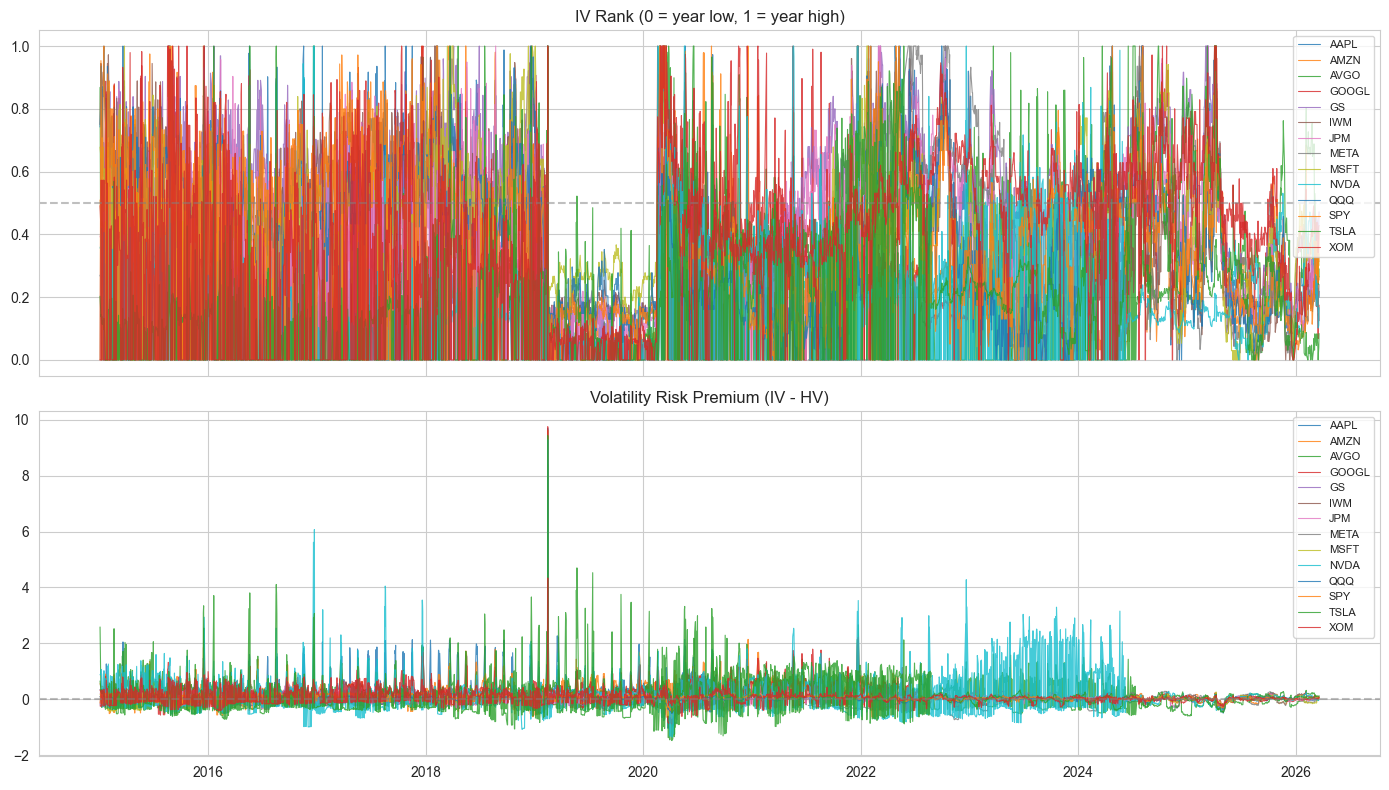

In [21]:
# IV rank and VRP over time
if vh is not None:
    # Compute IV rank if possible
    if 'iv_current' in vh.columns and 'iv_year_high' in vh.columns and 'iv_year_low' in vh.columns:
        vh['iv_rank'] = (vh['iv_current'] - vh['iv_year_low']) / (
            (vh['iv_year_high'] - vh['iv_year_low']).clip(lower=1e-6))
    if 'iv_current' in vh.columns and 'hv_current' in vh.columns:
        vh['vol_risk_premium'] = vh['iv_current'] - vh['hv_current']

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    for sym in sorted(vh['act_symbol'].unique()):
        mask = vh['act_symbol'] == sym
        sym_df = vh[mask].sort_values('date')

        if 'iv_rank' in vh.columns:
            axes[0].plot(sym_df['date'], sym_df['iv_rank'], label=sym, alpha=0.8, lw=0.8)
        if 'vol_risk_premium' in vh.columns:
            axes[1].plot(sym_df['date'], sym_df['vol_risk_premium'], label=sym, alpha=0.8, lw=0.8)

    if 'iv_rank' in vh.columns:
        axes[0].set_title('IV Rank (0 = year low, 1 = year high)')
        axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5)
        axes[0].legend(fontsize=8)
        axes[0].set_ylim(-0.05, 1.05)
    if 'vol_risk_premium' in vh.columns:
        axes[1].set_title('Volatility Risk Premium (IV - HV)')
        axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
        axes[1].legend(fontsize=8)
    plt.tight_layout()

## 5. Canonical Data Summary

In [22]:
if canonical_dir.exists():
    canonical_files = sorted(canonical_dir.glob('*.parquet'))
    print(f"Canonical files: {[f.name for f in canonical_files]}")

    for f in canonical_files:
        df = pd.read_parquet(f)
        print(f"\n{f.name}: {len(df):,} rows, {len(df.columns)} columns")
        print(f"  Columns: {list(df.columns)}")
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            print(f"  Dates: {df['date'].min()} -> {df['date'].max()}")
else:
    print(f"canonical_dir {canonical_dir} does not exist. Run `make canonical` first.")

Canonical files: ['market_state_canonical.parquet', 'options_canonical.parquet', 'underlying_canonical.parquet', 'vol_history_canonical.parquet']

market_state_canonical.parquet: 2,827 rows, 7 columns
  Columns: ['date', 'vix', 'spy_return', 'spy_pct_from_ma200', 'spy_adx14', 'spy_atr_ratio', 'risk_free_rate']
  Dates: 2014-12-19 00:00:00 -> 2026-03-19 00:00:00

options_canonical.parquet: 27,486,383 rows, 18 columns
  Columns: ['date', 'act_symbol', 'expiration', 'strike', 'call_put', 'bid', 'ask', 'iv', 'delta', 'gamma', 'theta', 'vega', 'rho', 'spot', 'moneyness', 'log_moneyness', 'tau', 'obs_frequency']
  Dates: 2015-01-02 00:00:00 -> 2026-03-19 00:00:00

underlying_canonical.parquet: 42,364 rows, 9 columns
  Columns: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'symbol', 'log_return']
  Dates: 2014-03-10 00:00:00 -> 2026-03-19 00:00:00

vol_history_canonical.parquet: 37,604 rows, 27 columns
  Columns: ['date', 'act_symbol', 'hv_current', 'hv_week_ago', 'hv_month_

## 6. Processed Tensors (Model Inputs)

In [23]:
import torch

sample_idx_path = processed_dir / 'sample_index.parquet'
if sample_idx_path.exists():
    sample_index = pd.read_parquet(sample_idx_path)
    print(f"Total samples: {len(sample_index):,}")
    print(f"Columns: {list(sample_index.columns)}")
    print(f"Dates: {sample_index['date'].min()} -> {sample_index['date'].max()}")
    print(f"Symbols: {sorted(sample_index['symbol'].unique())}")

    # Load one sample to inspect shapes
    row = sample_index.iloc[0]
    surf_path = processed_dir / 'surfaces' / f"{row['date']}_{row['symbol']}.pt"
    ret_path  = processed_dir / 'returns'  / f"{row['date']}_{row['symbol']}.pt"
    vh_path   = processed_dir / 'vol_history' / f"{row['date']}_{row['symbol']}.pt"
    mkt_path  = processed_dir / 'market_state' / f"{row['date']}_{row['symbol']}.pt"
    tgt_path  = processed_dir / 'targets' / f"{row['date']}_{row['symbol']}.pt"

    shapes = {}
    for name, path in [('surface', surf_path), ('returns', ret_path),
                        ('vol_history', vh_path), ('market_state', mkt_path),
                        ('targets', tgt_path)]:
        if path.exists():
            t = torch.load(path, weights_only=True)
            shapes[name] = t.shape
        else:
            shapes[name] = 'NOT FOUND'

    print("\nTensor shapes for first sample:")
    for name, shape in shapes.items():
        print(f"  {name:>15s}: {shape}")
else:
    print(f"No sample_index found at {sample_idx_path}. Run `make surfaces` first.")

Total samples: 25,783
Columns: ['date', 'symbol', 'surface_path', 'returns_path', 'vh_path', 'mkt_path', 'target_path', 'obs_frequency', 'is_gap_filled']
Dates: 2015-01-02 -> 2026-02-18
Symbols: ['AAPL', 'AMZN', 'AVGO', 'GOOGL', 'GS', 'IWM', 'JPM', 'META', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TSLA', 'XOM']

Tensor shapes for first sample:
          surface: NOT FOUND
          returns: NOT FOUND
      vol_history: NOT FOUND
     market_state: NOT FOUND
          targets: NOT FOUND


In [24]:
# Target distributions
if 'sample_index' in dir():
    n_samples = min(2000, len(sample_index))
    target_data = []
    for i in range(n_samples):
        row = sample_index.iloc[i]
        tgt_path = processed_dir / 'targets' / f"{row['date']}_{row['symbol']}.pt"
        if tgt_path.exists():
            t = torch.load(tgt_path, weights_only=True)
            target_data.append(t.numpy())

    if target_data:
        target_arr = np.stack(target_data)
        log_rvs = target_arr[:, 0]
        tail_labels = target_arr[:, 1]
        regime_labels = target_arr[:, 2]

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].hist(log_rvs, bins=50, color='steelblue', edgecolor='none')
        axes[0].set_title('Forward log(RV) Distribution')
        axes[0].set_xlabel('log(RV)')

        tail_counts = [int((tail_labels == 0).sum()), int((tail_labels == 1).sum())]
        axes[1].bar(['Normal', 'Tail Event'], tail_counts, color=['steelblue', 'coral'])
        axes[1].set_title(f'Tail-Risk Labels ({tail_counts[1]/sum(tail_counts):.1%} positive)')

        regime_names = ['bull_quiet', 'bull_vol', 'bear_quiet', 'bear_vol', 'side_quiet', 'side_vol']
        regime_counts = [int((regime_labels == k).sum()) for k in range(6)]
        colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c', '#9b59b6', '#95a5a6']
        axes[2].bar(regime_names, regime_counts, color=colors)
        axes[2].set_title('Regime Label Distribution')
        axes[2].tick_params(axis='x', rotation=45)

        plt.tight_layout()

## 7. Gap Analysis

Gap-filled samples: 0.0%
Gap policy: mark_stale
Max gap days: 5

Observation frequency breakdown:
obs_frequency
daily    25783
Name: count, dtype: int64

Obs weighting enabled: {'enabled': True, 'daily': 1.0, 'mwf': 0.8, 'weekly': 0.5}


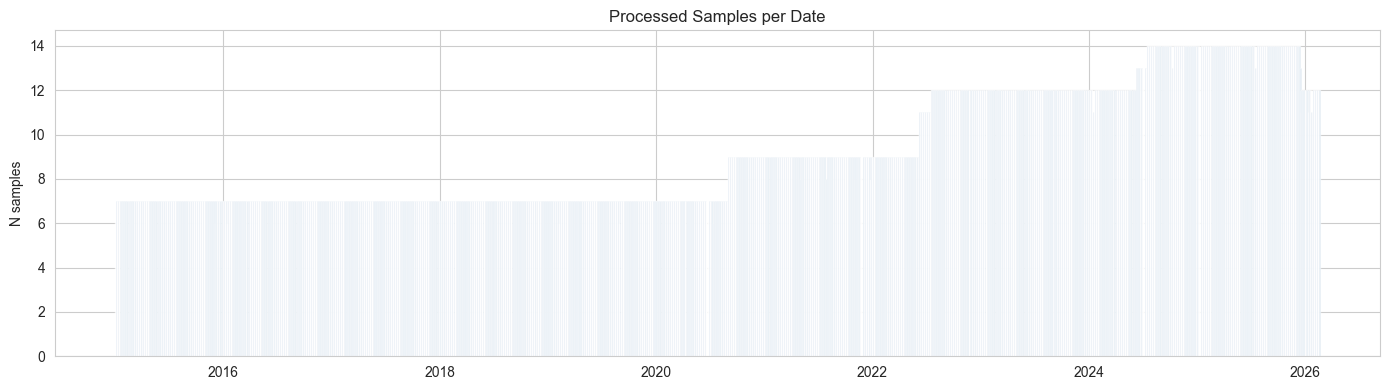

In [25]:
if 'sample_index' in dir():
    if 'is_gap_filled' in sample_index.columns:
        gap_pct = sample_index['is_gap_filled'].mean()
        print(f"Gap-filled samples: {gap_pct:.1%}")
        print(f"Gap policy: {cfg['data']['gaps']['policy']}")
        print(f"Max gap days: {cfg['data']['gaps']['max_gap_days']}")

    if 'obs_frequency' in sample_index.columns:
        print(f"\nObservation frequency breakdown:")
        print(sample_index['obs_frequency'].value_counts())

    if cfg['data']['obs_weighting']['enabled']:
        print(f"\nObs weighting enabled: {cfg['data']['obs_weighting']}")

    # Plot samples per date
    sample_index['date'] = pd.to_datetime(sample_index['date'])
    daily = sample_index.groupby('date').size()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(daily.index, daily.values, width=1, color='steelblue', alpha=0.7)
    ax.set_title('Processed Samples per Date')
    ax.set_ylabel('N samples')
    plt.tight_layout()